In [2]:
import numpy as np
import pandas as pd

In [30]:
data = pd.read_csv("data/train.csv").drop("id", axis = 1)
ori = pd.read_csv("data/ori.csv")
test = pd.read_csv("data/test.csv")

In [32]:
merged = pd.concat([data, ori], ignore_index=True)

In [33]:
merged

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.158750
1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.880560
2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.173200
3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.607930
4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.023120
...,...,...,...,...,...,...,...,...,...,...
352495,Jansport,Nylon,Medium,3.0,No,Yes,Messenger,Gray,19.774853,61.140497
352496,Jansport,NaN,Small,8.0,No,Yes,Messenger,Red,29.822417,47.140186
352497,Jansport,Polyester,Large,10.0,No,Yes,Messenger,Red,13.269034,56.184138
352498,Adidas,Canvas,Large,5.0,No,No,Messenger,Green,28.132229,112.036966


In [4]:
data

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,Adidas,Leather,Small,9.0,No,No,Tote,Blue,12.730812,129.99749
299996,299996,Jansport,Leather,Large,6.0,No,Yes,Tote,Blue,26.633182,19.85819
299997,299997,Puma,Canvas,Large,9.0,Yes,Yes,Backpack,Pink,11.898250,111.41364
299998,299998,Adidas,Nylon,Small,1.0,No,Yes,Tote,Pink,6.175738,115.89080


In [5]:
data.describe()

,id,Compartments,Weight Capacity (kg),Price
count,300000.000000,300000.000000,299862.000000,300000.000000
mean,149999.500000,5.443590,18.029994,81.411107
std,86602.684716,2.890766,6.966914,39.039340
min,0.000000,1.000000,5.000000,15.000000
25%,74999.750000,3.000000,12.097867,47.384620
50%,149999.500000,5.000000,18.068614,80.956120
75%,224999.250000,8.000000,24.002375,115.018160
max,299999.000000,10.000000,30.000000,150.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB


In [7]:
# from sklearn.preprocessing import LabelEncoder

# object_cols = [col for col in data.columns if data[col].dtype == 'object']
# le = LabelEncoder()
# for col in object_cols:
#     data[col] = le.fit_transform(data[col])
#     test[col] = le.transform(test[col])

In [ ]:
import seaborn as sns

sns.heatmap(data.corr())

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def get_price_dist(col = "Brand"):
    # Group by brand and calculate the average price
    top_brands = data.groupby(col)["Price"].mean().sort_values(ascending=False)
    
    # Plot the top brands with the highest average prices
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")

    # Annotate bars with price values
    for i, v in enumerate(top_brands.values):
        ax.text(i, v + 1, f"{v:.2f}", ha='center', fontsize=12, fontweight='bold')

    plt.xlabel(f"{col}")
    plt.ylabel("Average Price")
    plt.title(f"{col}with the Highest Average Price")
    plt.xticks(rotation=45)
    plt.show()

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


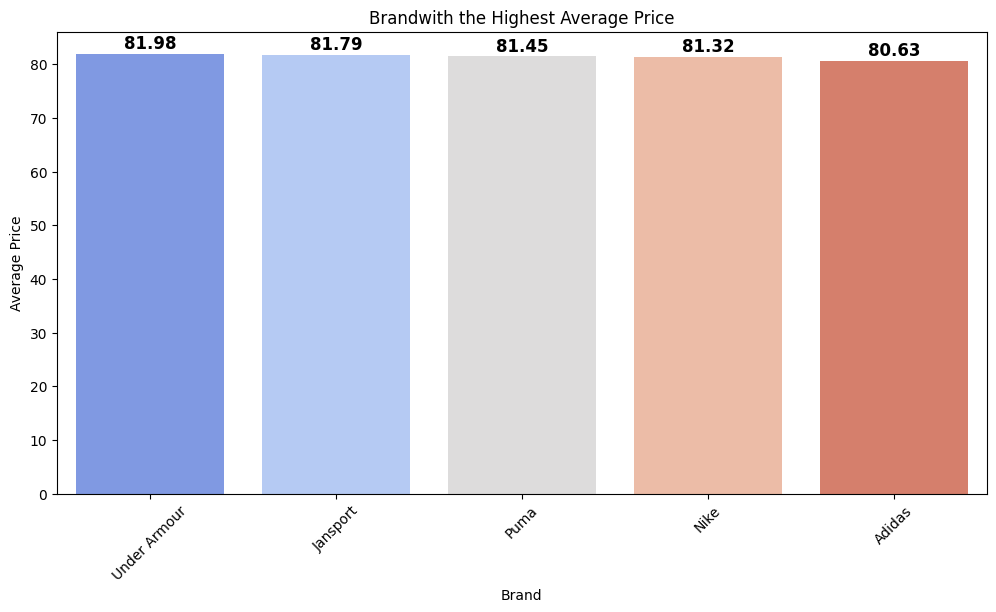

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


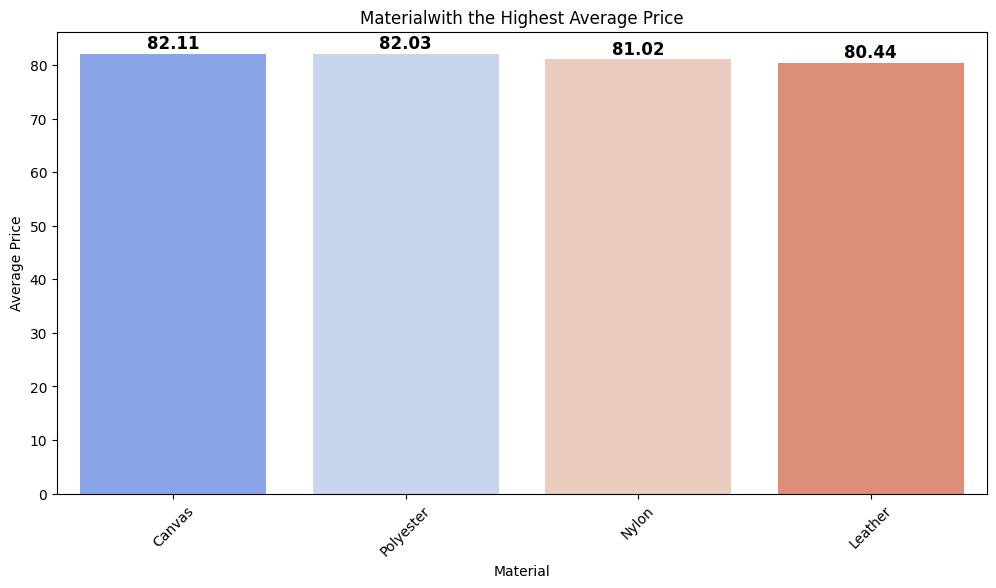

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


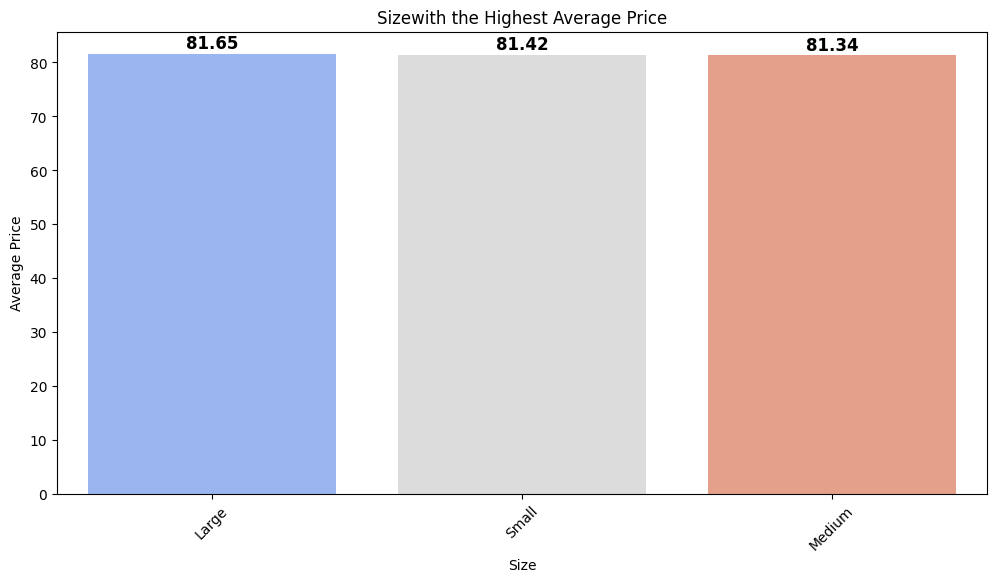

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


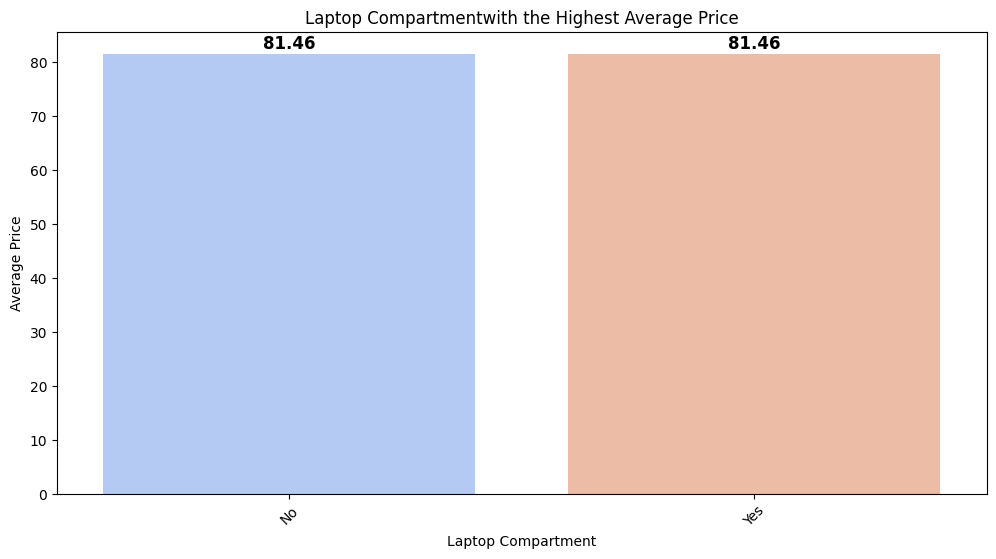

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


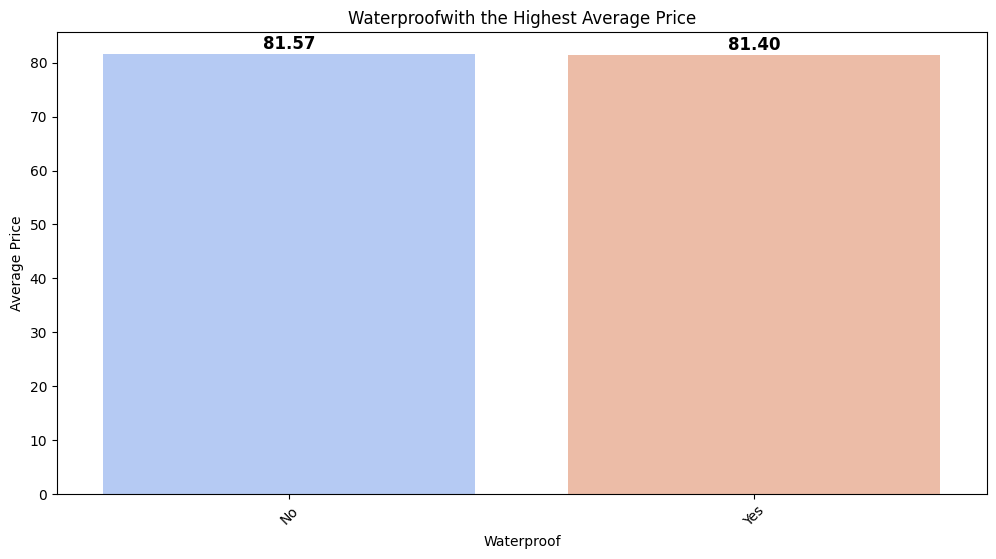

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


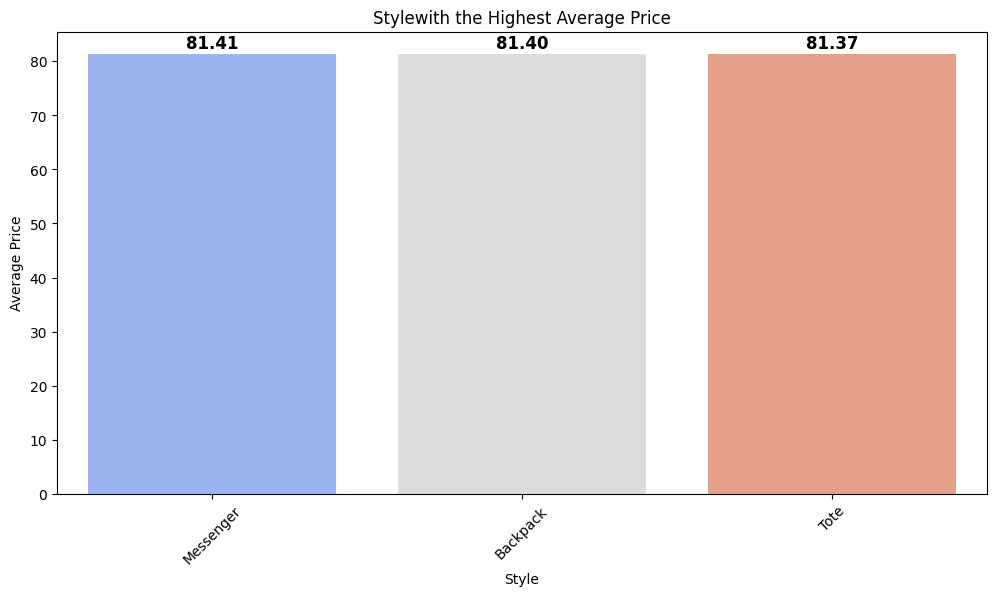

/var/folders/yh/mm99wdg51z314wrljpx090rm0000gn/T/ipykernel_6710/525757689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_brands.index, y=top_brands.values, palette="coolwarm")


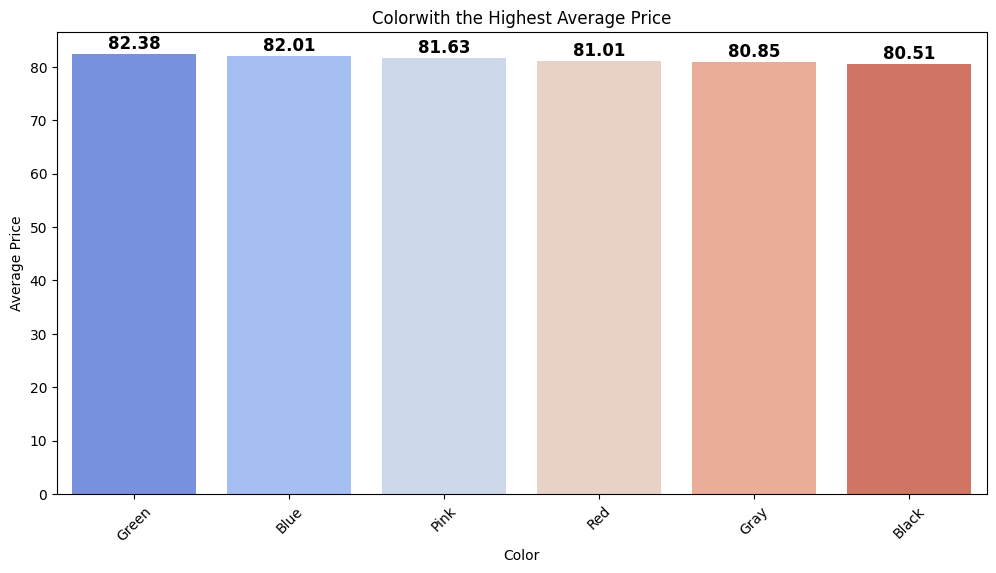

In [14]:
object_cols = [col for col in data.columns if data[col].dtype == 'object']
for i in object_cols:
    get_price_dist(i)

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

def get_price_flows(data, col="Brand"):
    # Get the top 5 brands based on the number of occurrences
    top_brands = data[col].value_counts().index

    # Plot the price distributions for each brand
    plt.figure(figsize=(12, 6))
    
    for brand in top_brands:
        sns.kdeplot(data[data[col] == brand]["Price"], label=brand, linewidth=2)

    plt.xlabel("Price")
    plt.ylabel("Density")
    plt.title(f"Price Distribution for Top 5 {col}s")
    plt.legend(title=col)
    plt.show()

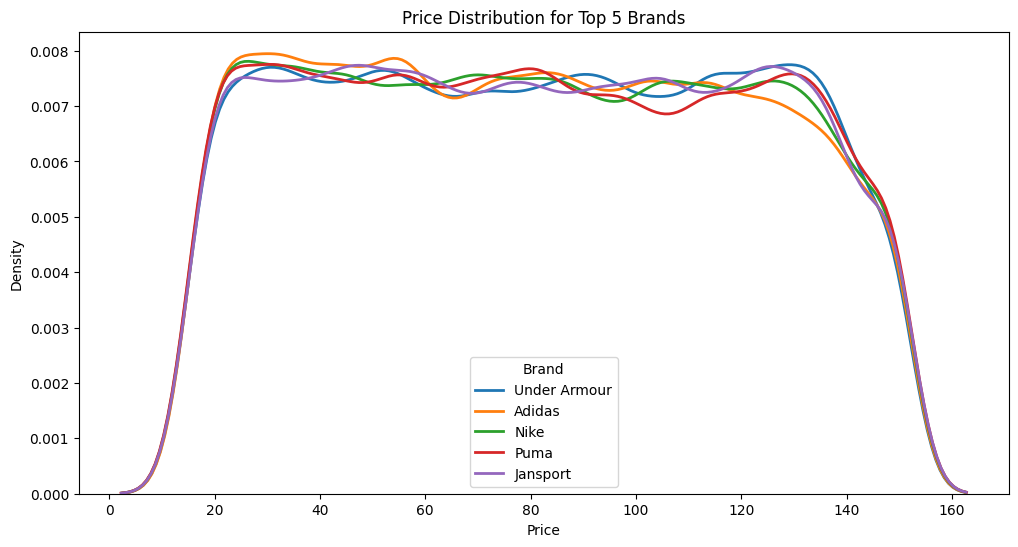

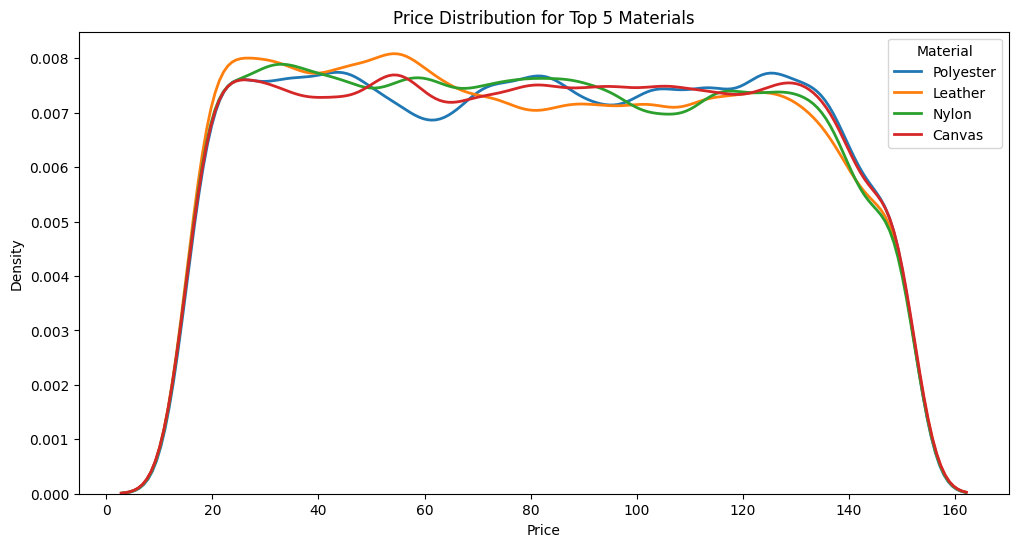

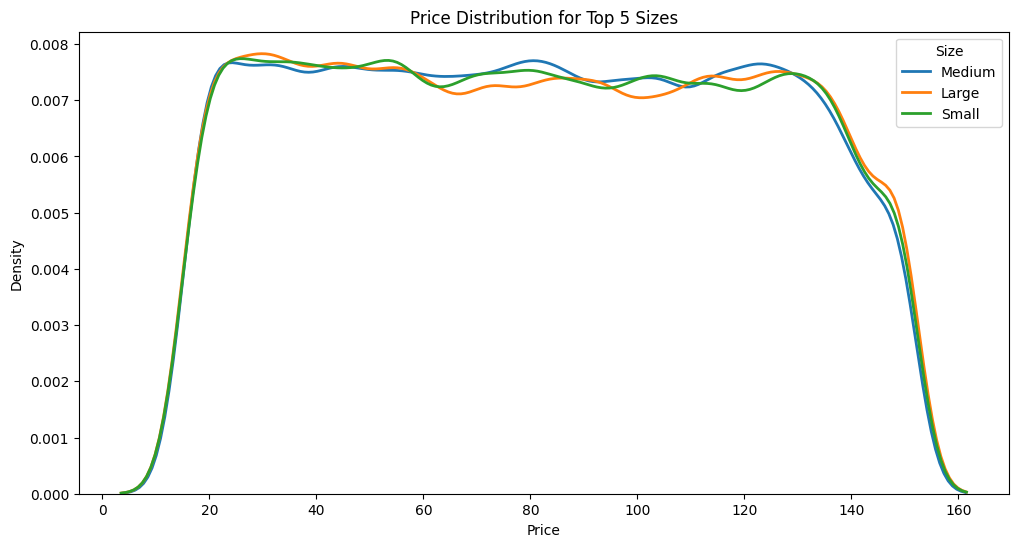

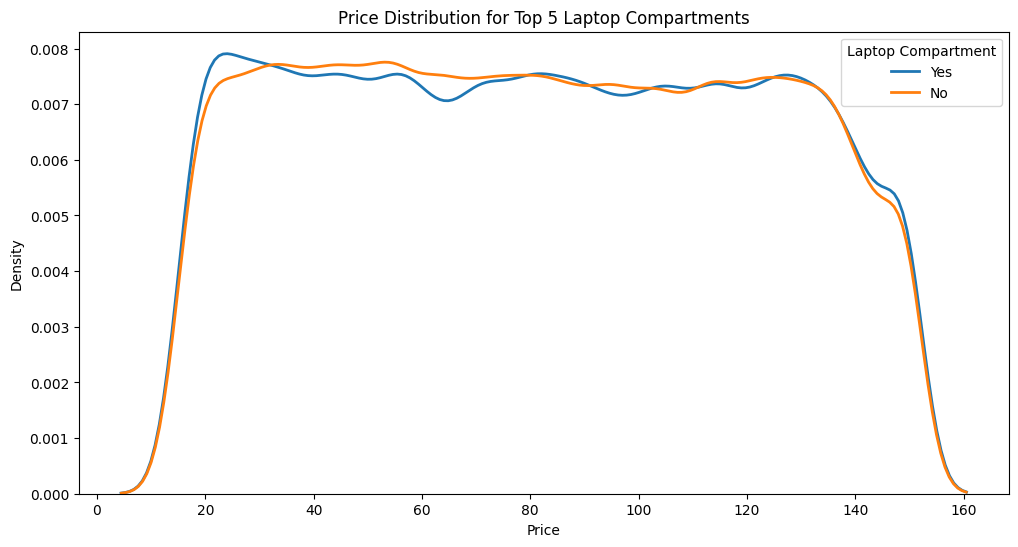

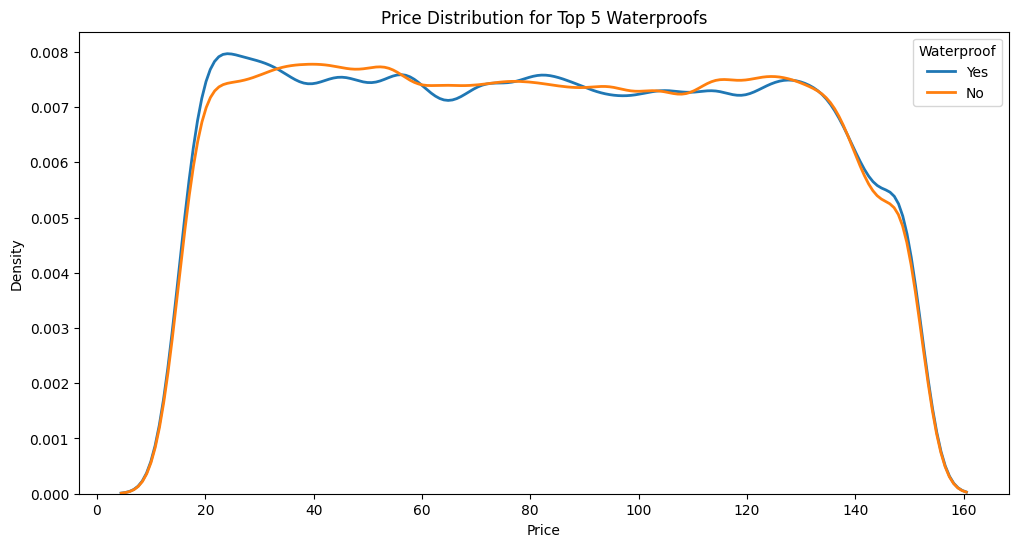

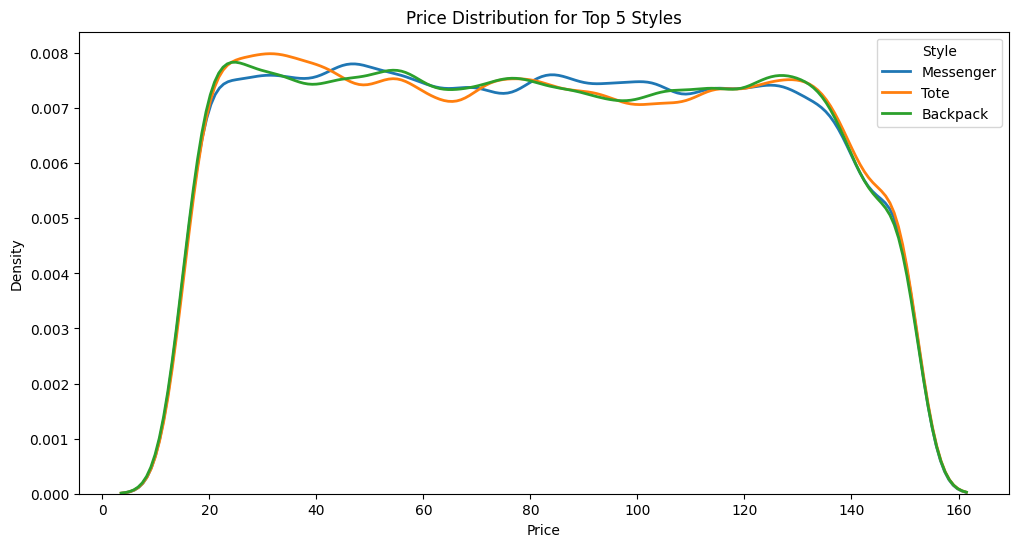

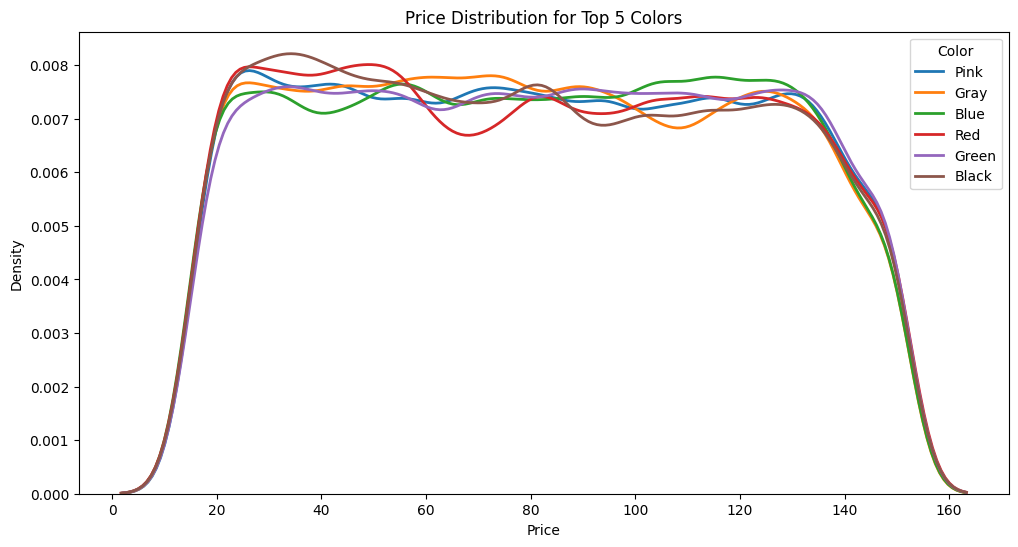

In [36]:
object_cols = [col for col in data.columns if data[col].dtype == 'object']
for i in object_cols:
    get_price_flows(merged, i)

In [20]:
data.columns

Index(['id', 'Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment',
       'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)', 'Price'],
      dtype='object')